In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import nbformat
import warnings
warnings.filterwarnings('ignore')

In [17]:
data = pd.read_csv("/Users/jjburrell/Downloads/world-data-2023.csv")
data

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
0,Afghanistan,60,AF,58.10%,"652,230","323,000",32.49,93.0,Kabul,"8,672",...,78.40%,0.28,"38,041,754",48.90%,9.30%,71.40%,11.12%,"9,797,273",33.939110,67.709953
1,Albania,105,AL,43.10%,"28,748","9,000",11.78,355.0,Tirana,"4,536",...,56.90%,1.20,"2,854,191",55.70%,18.60%,36.60%,12.33%,"1,747,593",41.153332,20.168331
2,Algeria,18,DZ,17.40%,"2,381,741","317,000",24.28,213.0,Algiers,"150,006",...,28.10%,1.72,"43,053,054",41.20%,37.20%,66.10%,11.70%,"31,510,100",28.033886,1.659626
3,Andorra,164,AD,40.00%,468,NaN,7.20,376.0,Andorra la Vella,469,...,36.40%,3.33,"77,142",NaN,NaN,NaN,NaN,"67,873",42.506285,1.521801
4,Angola,26,AO,47.50%,"1,246,700","117,000",40.73,244.0,Luanda,"34,693",...,33.40%,0.21,"31,825,295",77.50%,9.20%,49.10%,6.89%,"21,061,025",-11.202692,17.873887
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,Venezuela,32,VE,24.50%,"912,050","343,000",17.88,58.0,Caracas,"164,175",...,45.80%,1.92,"28,515,829",59.70%,NaN,73.30%,8.80%,"25,162,368",6.423750,-66.589730
191,Vietnam,314,VN,39.30%,"331,210","522,000",16.75,84.0,Hanoi,"192,668",...,43.50%,0.82,"96,462,106",77.40%,19.10%,37.60%,2.01%,"35,332,140",14.058324,108.277199
192,Yemen,56,YE,44.60%,"527,968","40,000",30.45,967.0,Sanaa,"10,609",...,81.00%,0.31,"29,161,922",38.00%,NaN,26.60%,12.91%,"10,869,523",15.552727,48.516388
193,Zambia,25,ZM,32.10%,"752,618","16,000",36.19,260.0,Lusaka,"5,141",...,27.50%,1.19,"17,861,030",74.60%,16.20%,15.60%,11.43%,"7,871,713",-13.133897,27.849332


In [18]:
data.head()

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
0,Afghanistan,60,AF,58.10%,"652,230","323,000",32.49,93.0,Kabul,"8,672",...,78.40%,0.28,"38,041,754",48.90%,9.30%,71.40%,11.12%,"9,797,273",33.939110,67.709953
1,Albania,105,AL,43.10%,"28,748","9,000",11.78,355.0,Tirana,"4,536",...,56.90%,1.20,"2,854,191",55.70%,18.60%,36.60%,12.33%,"1,747,593",41.153332,20.168331
2,Algeria,18,DZ,17.40%,"2,381,741","317,000",24.28,213.0,Algiers,"150,006",...,28.10%,1.72,"43,053,054",41.20%,37.20%,66.10%,11.70%,"31,510,100",28.033886,1.659626
3,Andorra,164,AD,40.00%,468,NaN,7.20,376.0,Andorra la Vella,469,...,36.40%,3.33,"77,142",NaN,NaN,NaN,NaN,"67,873",42.506285,1.521801
4,Angola,26,AO,47.50%,"1,246,700","117,000",40.73,244.0,Luanda,"34,693",...,33.40%,0.21,"31,825,295",77.50%,9.20%,49.10%,6.89%,"21,061,025",-11.202692,17.873887


In [19]:
data.tail()

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
190,Venezuela,32,VE,24.50%,"912,050","343,000",17.88,58.0,Caracas,"164,175",...,45.80%,1.92,"28,515,829",59.70%,NaN,73.30%,8.80%,"25,162,368",6.423750,-66.589730
191,Vietnam,314,VN,39.30%,"331,210","522,000",16.75,84.0,Hanoi,"192,668",...,43.50%,0.82,"96,462,106",77.40%,19.10%,37.60%,2.01%,"35,332,140",14.058324,108.277199
192,Yemen,56,YE,44.60%,"527,968","40,000",30.45,967.0,Sanaa,"10,609",...,81.00%,0.31,"29,161,922",38.00%,NaN,26.60%,12.91%,"10,869,523",15.552727,48.516388
193,Zambia,25,ZM,32.10%,"752,618","16,000",36.19,260.0,Lusaka,"5,141",...,27.50%,1.19,"17,861,030",74.60%,16.20%,15.60%,11.43%,"7,871,713",-13.133897,27.849332
194,Zimbabwe,38,ZW,41.90%,"390,757","51,000",30.68,263.0,Harare,"10,983",...,25.80%,0.21,"14,645,468",83.10%,20.70%,31.60%,4.95%,"4,717,305",-19.015438,29.154857


In [20]:
data.sample(10)

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
86,Jordan,115,JO,12.00%,"89,342","116,000",21.98,962.0,Amman,"25,108",...,25.10%,2.32,"10,101,694",39.30%,15.10%,28.60%,14.72%,"9,213,048",30.585164,36.238414
52,El Salvador,313,SV,76.40%,"21,041","42,000",18.25,503.0,San Salvador,"7,169",...,27.90%,1.57,"6,453,553",59.10%,18.10%,36.40%,4.11%,"4,694,702",13.794185,-88.896530
12,Bahrain,"2,239",BH,11.10%,765,"19,000",13.99,973.0,Manama,"31,694",...,25.10%,0.93,"1,501,635",73.40%,4.20%,13.80%,0.71%,"1,467,109",26.066700,50.557700
134,Panama,58,PA,30.40%,"75,420","26,000",18.98,507.0,Panama City,"10,715",...,30.50%,1.57,"4,246,439",66.60%,NaN,37.20%,3.90%,"2,890,084",8.537981,-80.782127
31,Cameroon,56,CM,20.60%,"475,440","24,000",35.39,237.0,Yaound�,"8,291",...,69.70%,0.09,"25,876,380",76.10%,12.80%,57.70%,3.38%,"14,741,256",7.369722,12.354722
156,Singapore,"8,358",SG,0.90%,716,"81,000",8.80,65.0,NaN,"37,535",...,36.70%,2.29,"5,703,569",70.50%,13.10%,21.00%,4.11%,"5,703,569",1.352083,103.819836
193,Zambia,25,ZM,32.10%,"752,618","16,000",36.19,260.0,Lusaka,"5,141",...,27.50%,1.19,"17,861,030",74.60%,16.20%,15.60%,11.43%,"7,871,713",-13.133897,27.849332
178,Tunisia,76,TN,64.80%,"163,610","48,000",17.56,216.0,Tunis,"29,937",...,39.80%,1.30,"11,694,719",46.10%,21.10%,60.70%,16.02%,"8,099,061",33.886917,9.537499
128,North Macedonia,83,NaN,NaN,"25,713",NaN,NaN,389.0,Skopje,NaN,...,35.60%,NaN,"1,836,713",NaN,NaN,NaN,NaN,NaN,41.608635,21.745275
63,Georgia,57,GE,34.50%,"69,700","26,000",13.47,995.0,Tbilisi,"10,128",...,57.30%,7.12,"3,720,382",68.30%,21.70%,9.90%,14.40%,"2,196,476",42.315407,43.356892


In [21]:
data.shape

(195, 35)

In [22]:
data.columns

Index(['Country', 'Density\n(P/Km2)', 'Abbreviation', 'Agricultural Land( %)',
       'Land Area(Km2)', 'Armed Forces size', 'Birth Rate', 'Calling Code',
       'Capital/Major City', 'Co2-Emissions', 'CPI', 'CPI Change (%)',
       'Currency-Code', 'Fertility Rate', 'Forested Area (%)',
       'Gasoline Price', 'GDP', 'Gross primary education enrollment (%)',
       'Gross tertiary education enrollment (%)', 'Infant mortality',
       'Largest city', 'Life expectancy', 'Maternal mortality ratio',
       'Minimum wage', 'Official language', 'Out of pocket health expenditure',
       'Physicians per thousand', 'Population',
       'Population: Labor force participation (%)', 'Tax revenue (%)',
       'Total tax rate', 'Unemployment rate', 'Urban_population', 'Latitude',
       'Longitude'],
      dtype='object')

In [23]:
data.duplicated().sum

<bound method Series.sum of 0      False
1      False
2      False
3      False
4      False
       ...  
190    False
191    False
192    False
193    False
194    False
Length: 195, dtype: bool>

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 35 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Country                                    195 non-null    object 
 1   Density
(P/Km2)                            195 non-null    object 
 2   Abbreviation                               188 non-null    object 
 3   Agricultural Land( %)                      188 non-null    object 
 4   Land Area(Km2)                             194 non-null    object 
 5   Armed Forces size                          171 non-null    object 
 6   Birth Rate                                 189 non-null    float64
 7   Calling Code                               194 non-null    float64
 8   Capital/Major City                         192 non-null    object 
 9   Co2-Emissions                              188 non-null    object 
 10  CPI                       

In [25]:
data.describe()

,Birth Rate,Calling Code,Fertility Rate,Infant mortality,Life expectancy,Maternal mortality ratio,Physicians per thousand,Latitude,Longitude
count,189.000000,194.000000,188.000000,189.000000,187.000000,181.000000,188.000000,194.000000,194.000000
mean,20.214974,360.546392,2.698138,21.332804,72.279679,160.392265,1.839840,19.092351,20.232434
std,9.945774,323.236419,1.282267,19.548058,7.483661,233.502024,1.684261,23.961779,66.716110
min,5.900000,1.000000,0.980000,1.400000,52.800000,2.000000,0.010000,-40.900557,-175.198242
25%,11.300000,82.500000,1.705000,6.000000,67.000000,13.000000,0.332500,4.544175,-7.941496
50%,17.950000,255.500000,2.245000,14.000000,73.200000,53.000000,1.460000,17.273849,20.972652
75%,28.750000,506.750000,3.597500,32.700000,77.500000,186.000000,2.935000,40.124603,48.281523
max,46.080000,1876.000000,6.910000,84.500000,85.400000,1150.000000,8.420000,64.963051,178.065032


In [26]:
data.nunique()

Country                                      195
Density\n(P/Km2)                             137
Abbreviation                                 188
Agricultural Land( %)                        168
Land Area(Km2)                               194
Armed Forces size                            105
Birth Rate                                   170
Calling Code                                 182
Capital/Major City                           192
Co2-Emissions                                184
CPI                                          175
CPI Change (%)                                86
Currency-Code                                133
Fertility Rate                               139
Forested Area (%)                            161
Gasoline Price                               101
GDP                                          193
Gross primary education enrollment (%)       141
Gross tertiary education enrollment (%)      171
Infant mortality                             144
Largest city        

In [27]:
data.dtypes

Country                                       object
Density\n(P/Km2)                              object
Abbreviation                                  object
Agricultural Land( %)                         object
Land Area(Km2)                                object
Armed Forces size                             object
Birth Rate                                   float64
Calling Code                                 float64
Capital/Major City                            object
Co2-Emissions                                 object
CPI                                           object
CPI Change (%)                                object
Currency-Code                                 object
Fertility Rate                               float64
Forested Area (%)                             object
Gasoline Price                                object
GDP                                           object
Gross primary education enrollment (%)        object
Gross tertiary education enrollment (%)       

In [28]:
data.isnull().sum()

Country                                       0
Density\n(P/Km2)                              0
Abbreviation                                  7
Agricultural Land( %)                         7
Land Area(Km2)                                1
Armed Forces size                            24
Birth Rate                                    6
Calling Code                                  1
Capital/Major City                            3
Co2-Emissions                                 7
CPI                                          17
CPI Change (%)                               16
Currency-Code                                15
Fertility Rate                                7
Forested Area (%)                             7
Gasoline Price                               20
GDP                                           2
Gross primary education enrollment (%)        7
Gross tertiary education enrollment (%)      12
Infant mortality                              6
Largest city                            

In [29]:
num_cols = data.select_dtypes(include=['float64']).columns
data[num_cols]=data[num_cols].apply(lambda col: col.fillna(col.median()))
obj_cols=data.select_dtypes(include=['object']).columns
data[obj_cols]=data[obj_cols].apply(lambda col: col.fillna(col.mode()[0]))

In [30]:
data.isnull().sum()

Country                                      0
Density\n(P/Km2)                             0
Abbreviation                                 0
Agricultural Land( %)                        0
Land Area(Km2)                               0
Armed Forces size                            0
Birth Rate                                   0
Calling Code                                 0
Capital/Major City                           0
Co2-Emissions                                0
CPI                                          0
CPI Change (%)                               0
Currency-Code                                0
Fertility Rate                               0
Forested Area (%)                            0
Gasoline Price                               0
GDP                                          0
Gross primary education enrollment (%)       0
Gross tertiary education enrollment (%)      0
Infant mortality                             0
Largest city                                 0
Life expectan

In [31]:
num_cols=["GDP","Unemployment rate","Co2-Emissions","Population"]
for col in num_cols:
    data[col]= data[col].astype(str).str.replace(r"[$,%]","",regex=True).astype(float)

Visualization

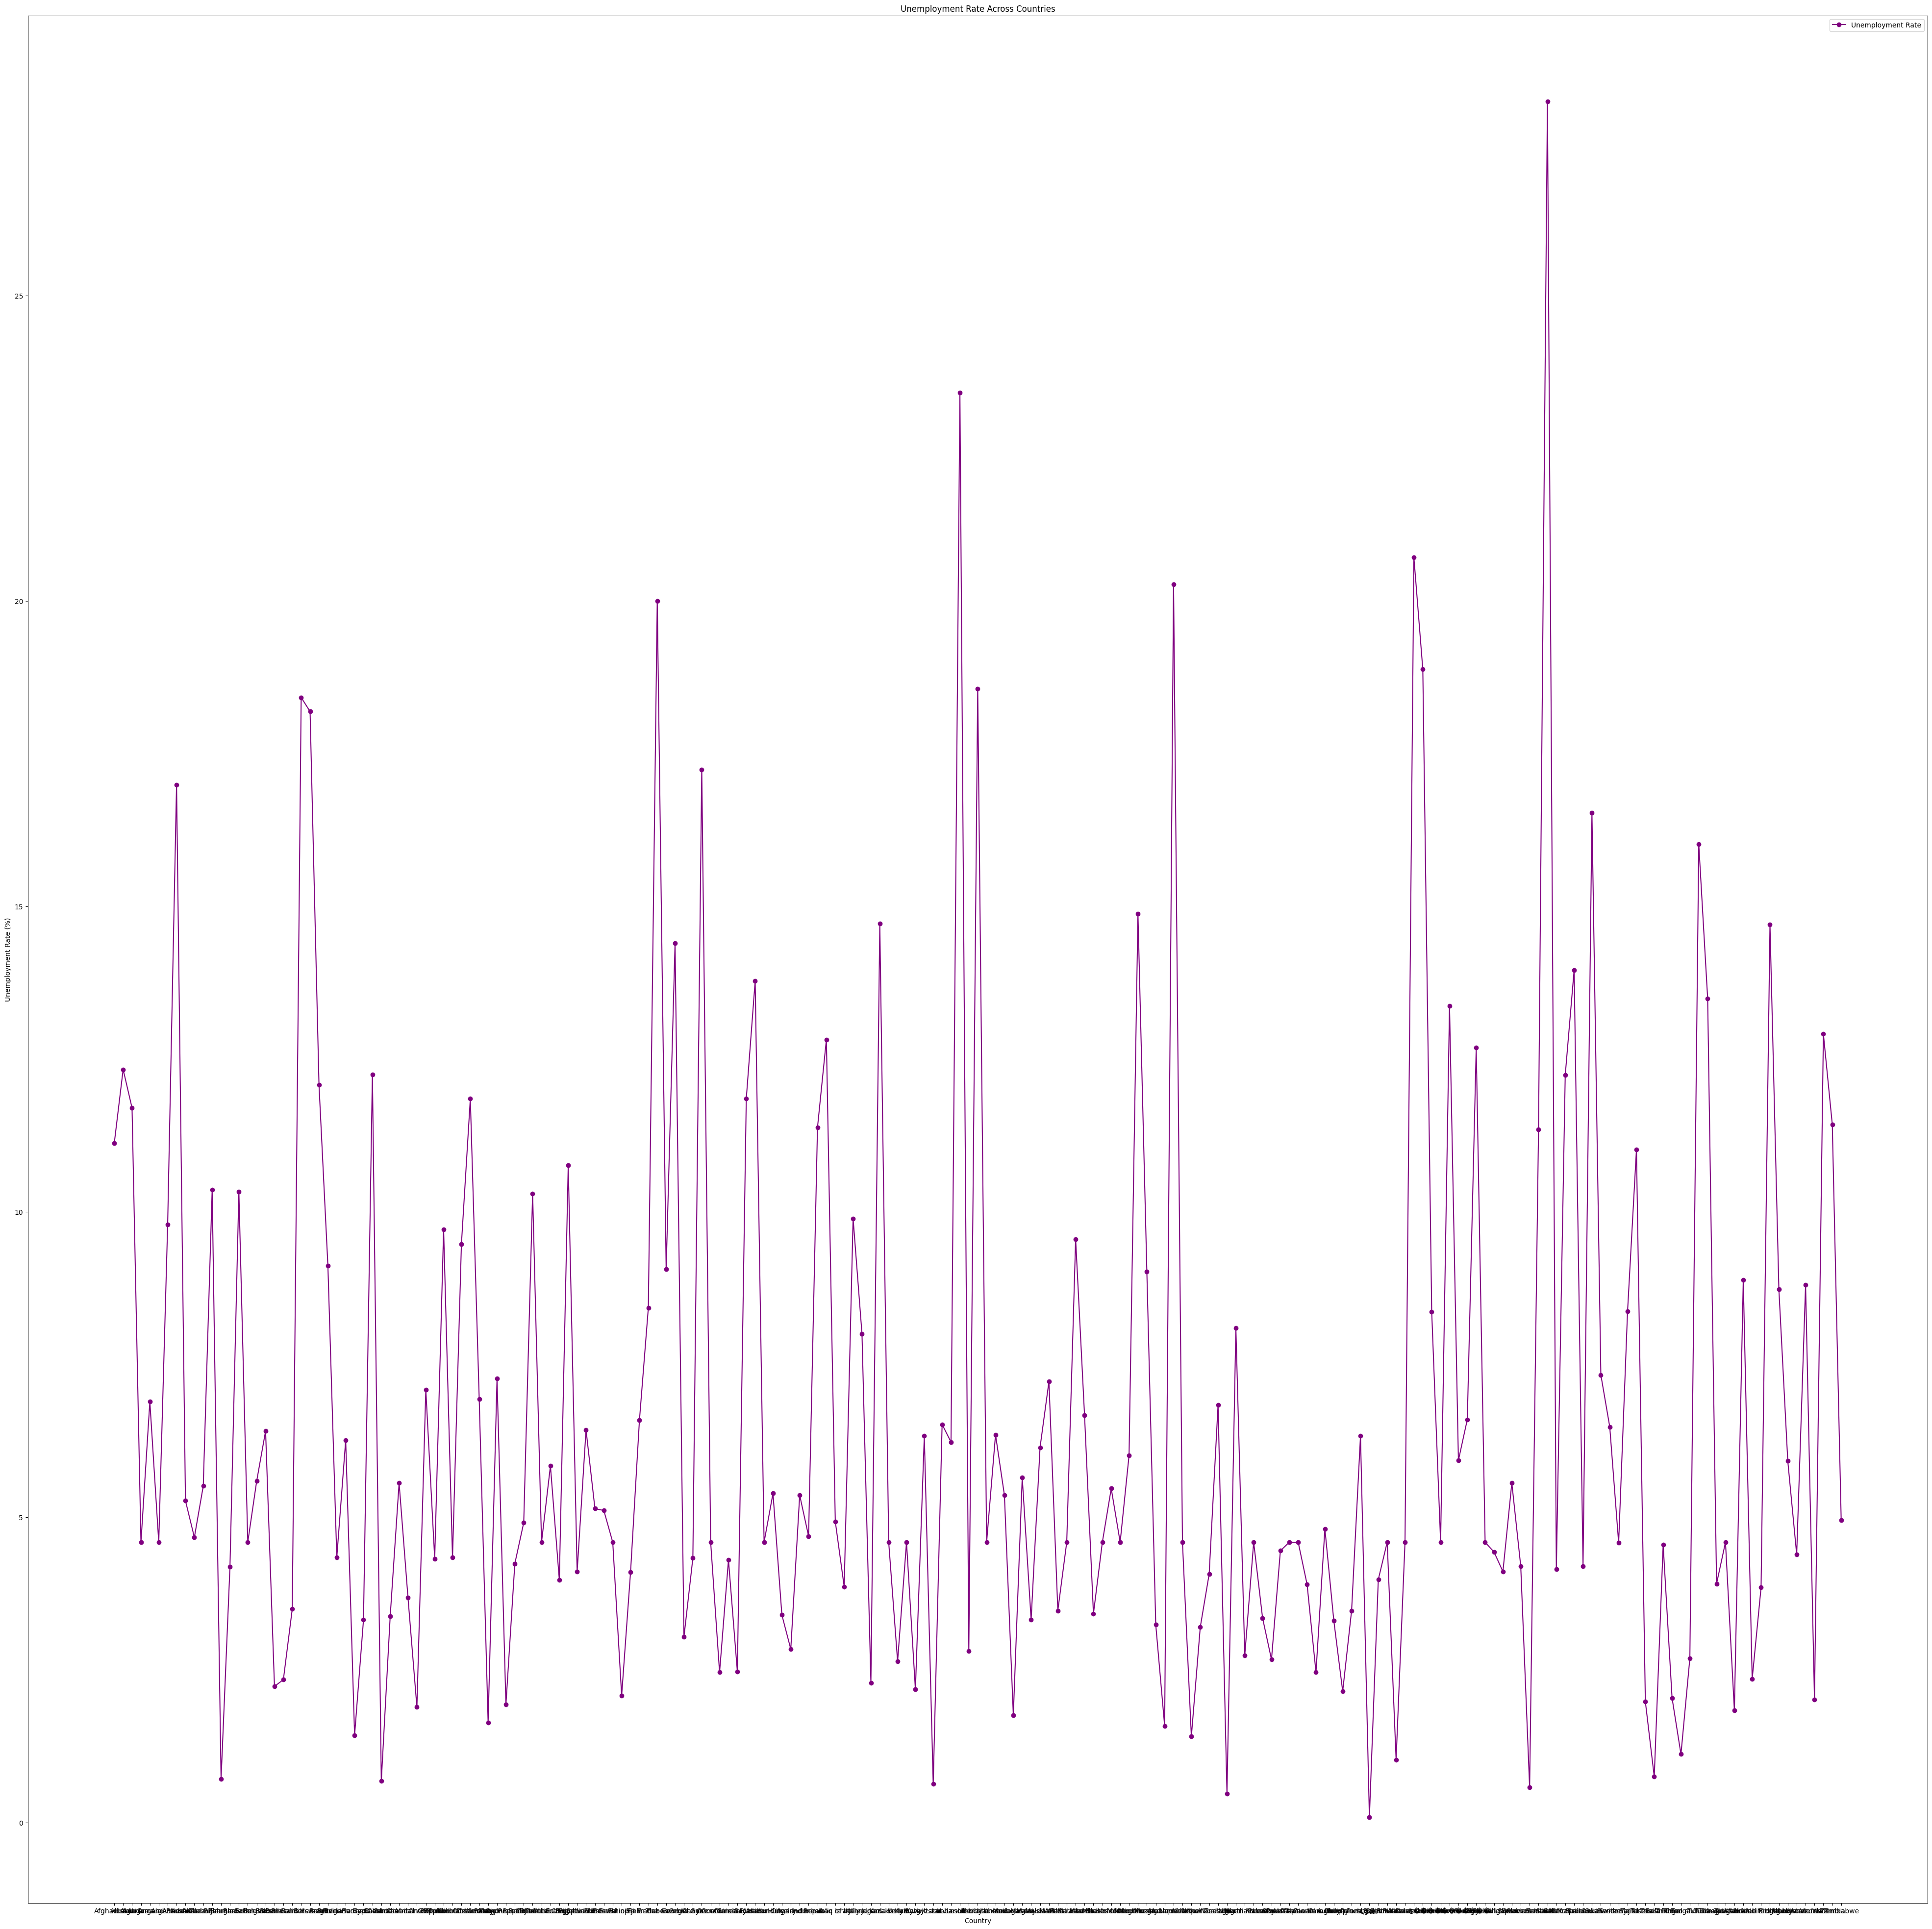

In [32]:
#Line Plot
plt.figure(figsize=(50, 50))
plt.plot(data["Country"], data["Unemployment rate"], marker="o", linestyle="-", color="purple", label="Unemployment Rate")
plt.xlabel("Country")
plt.ylabel("Unemployment Rate (%)")
plt.title("Unemployment Rate Across Countries")
plt.legend()
plt.show()

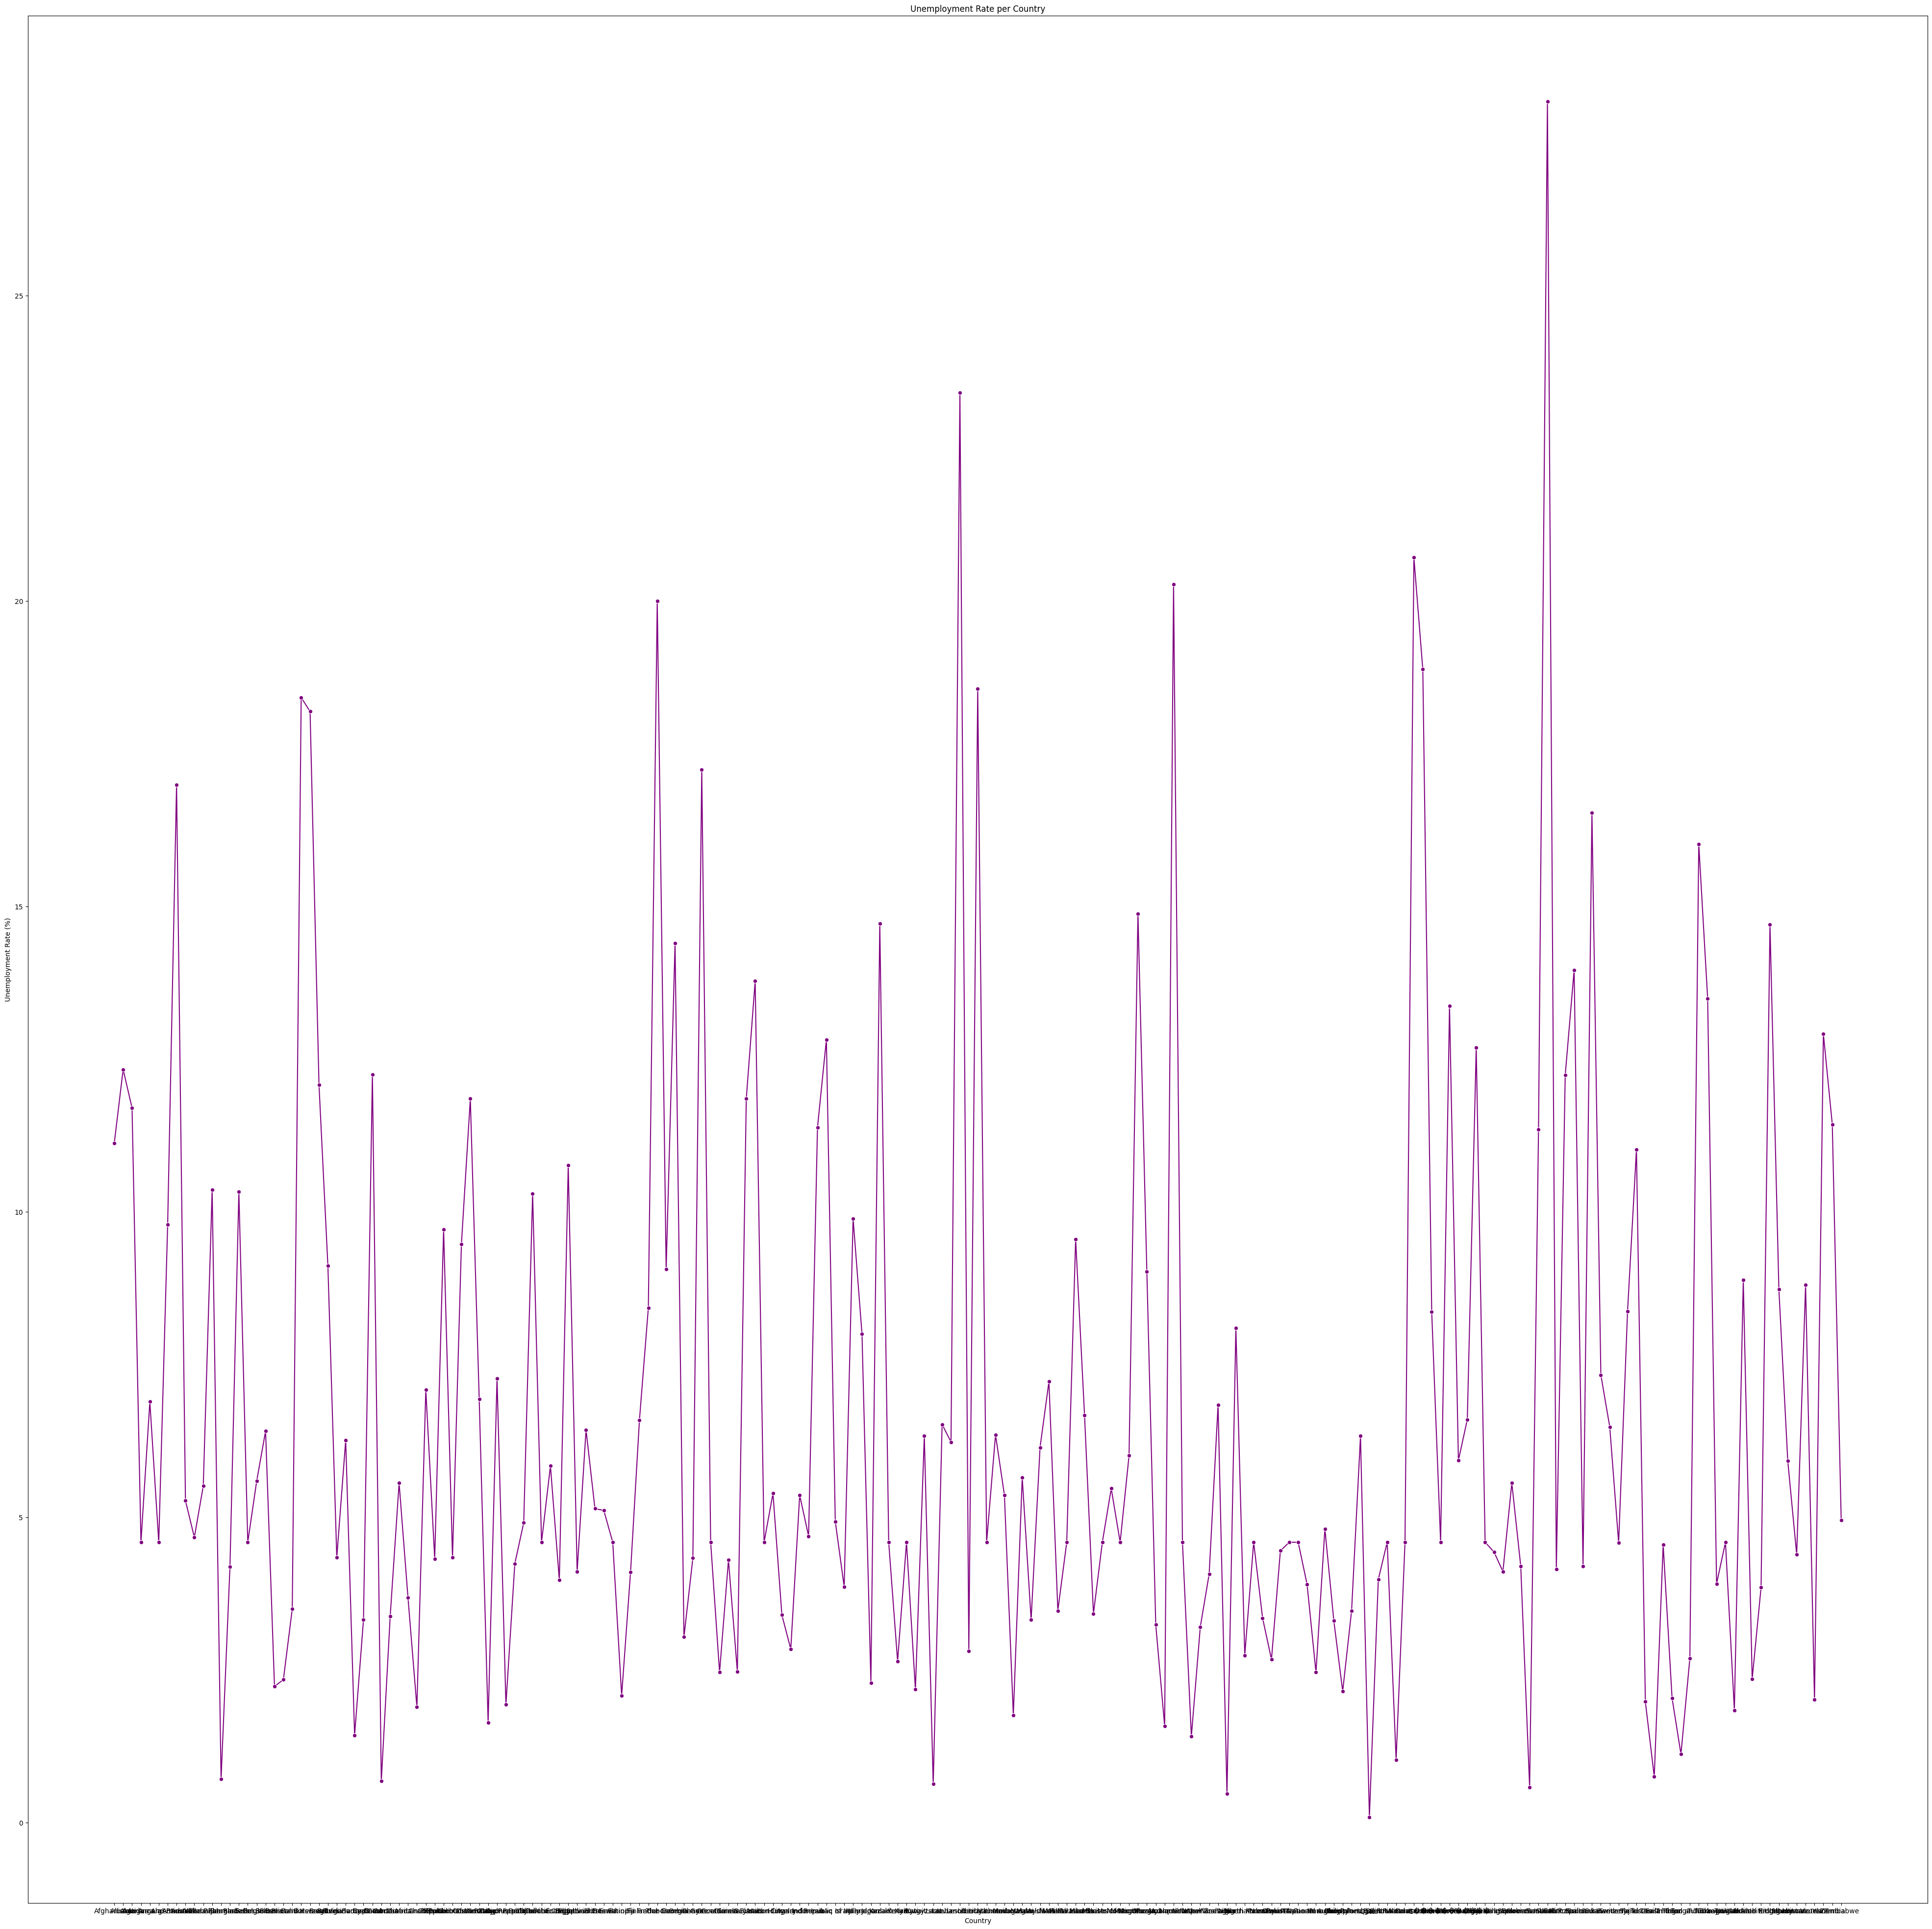

In [33]:
plt.figure(figsize=(50, 50))
sns.lineplot(x="Country", y="Unemployment rate", data=data, marker="o", color="purple")
plt.xlabel("Country")
plt.ylabel("Unemployment Rate (%)")
plt.title("Unemployment Rate per Country")
plt.show()


In [37]:
fig = px.line(data, x="Country", y="Unemployment rate", markers=True, title="Unemployment Rate Across Countries", line_shape="linear", color_discrete_sequence=["purple"])
fig.update_layout(xaxis=dict(tickangle=-90))
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

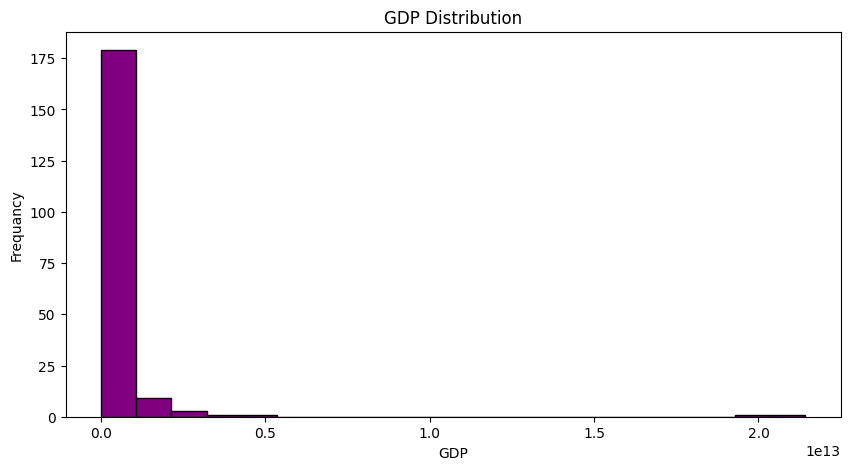

In [38]:
#Histogram
plt.figure(figsize=(10,5))
plt.hist(data["GDP"],bins=20,color="purple",edgecolor="black")
plt.xlabel("GDP")
plt.ylabel("Frequancy")
plt.title("GDP Distribution")
plt.show()

Text(0.5, 1.0, 'Distribution of population')

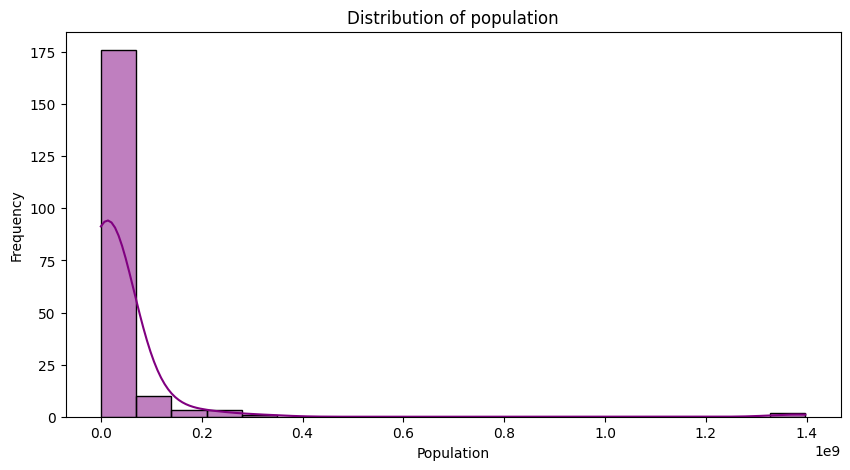

In [39]:
plt.figure(figsize=(10,5))
sns.histplot(data["Population"], bins=20, kde=True,color="purple")
plt.xlabel("Population")
plt.ylabel("Frequency")
plt.title("Distribution of population")

In [40]:
fig = px.histogram(data, x="GDP", nbins=20, title="GDP Distripution")
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Text(0.5, 1.0, 'GDP vs Co2-Emissions')

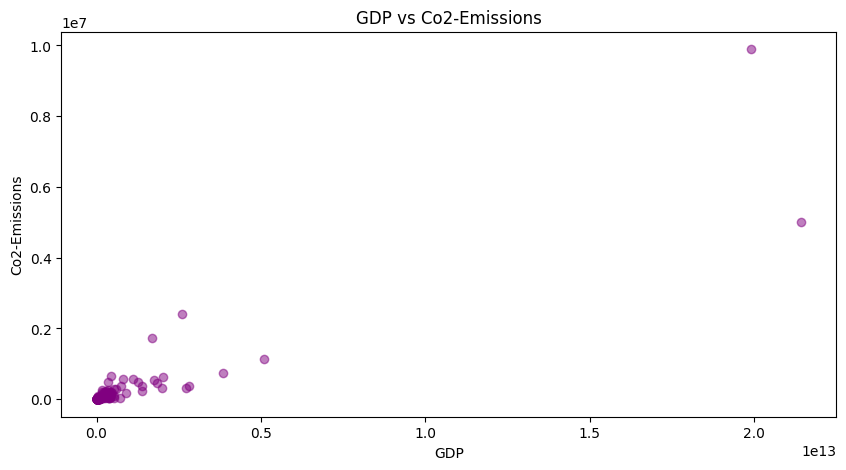

In [41]:
#Scatter Plot
plt.figure(figsize=(10,5))
plt.scatter(data["GDP"],data["Co2-Emissions"],color="purple",alpha=0.5)
plt.xlabel("GDP")
plt.ylabel("Co2-Emissions")
plt.title("GDP vs Co2-Emissions")

Text(0.5, 1.0, 'GDP vs Co2-Emissions')

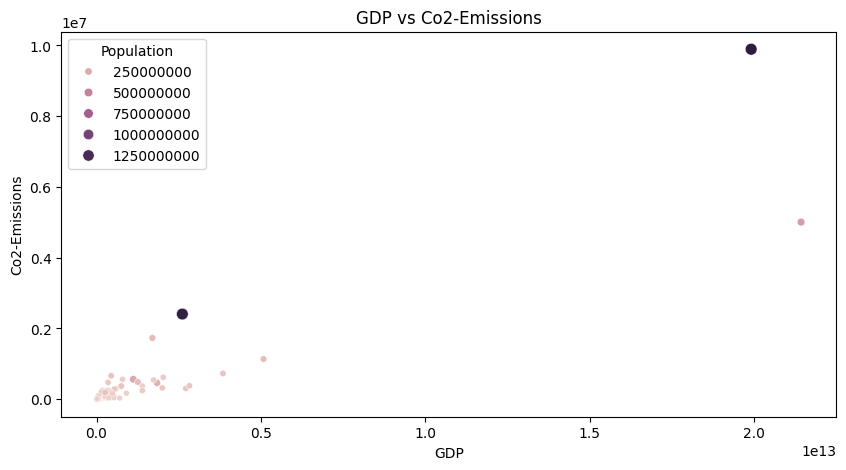

In [42]:
plt.figure(figsize=(10,5))
sns.scatterplot(x=data["GDP"], y=data["Co2-Emissions"],hue=data["Population"],size=data["Population"])
plt.xlabel("GDP")
plt.ylabel("Co2-Emissions")
plt.title("GDP vs Co2-Emissions")

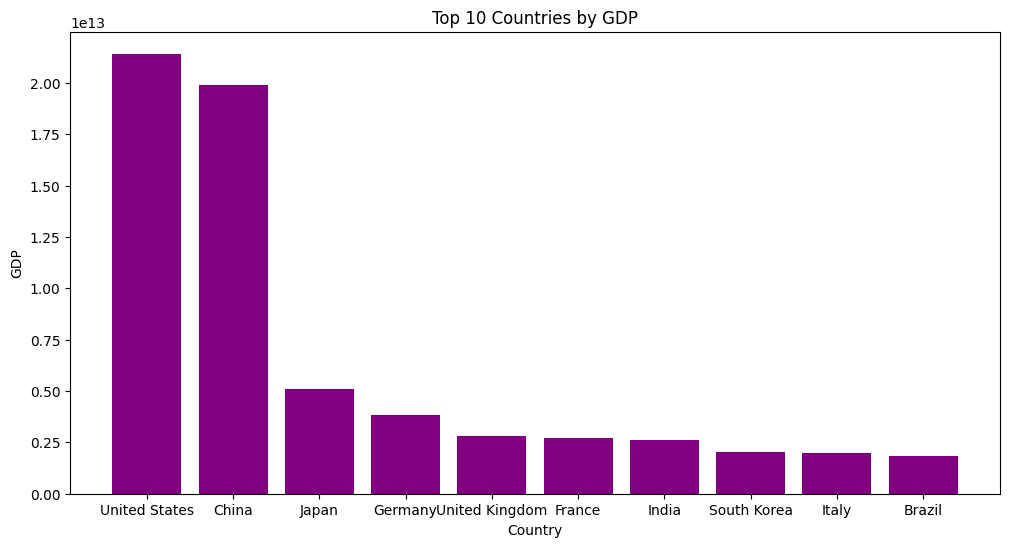

In [43]:
#Bar Chart
top_countries=data.nlargest(10,"GDP")
plt.figure(figsize=(12,6))
plt.bar(top_countries["Country"], top_countries["GDP"], color="purple")
plt.xlabel("Country")
plt.ylabel("GDP")
plt.title("Top 10 Countries by GDP")
plt.show()

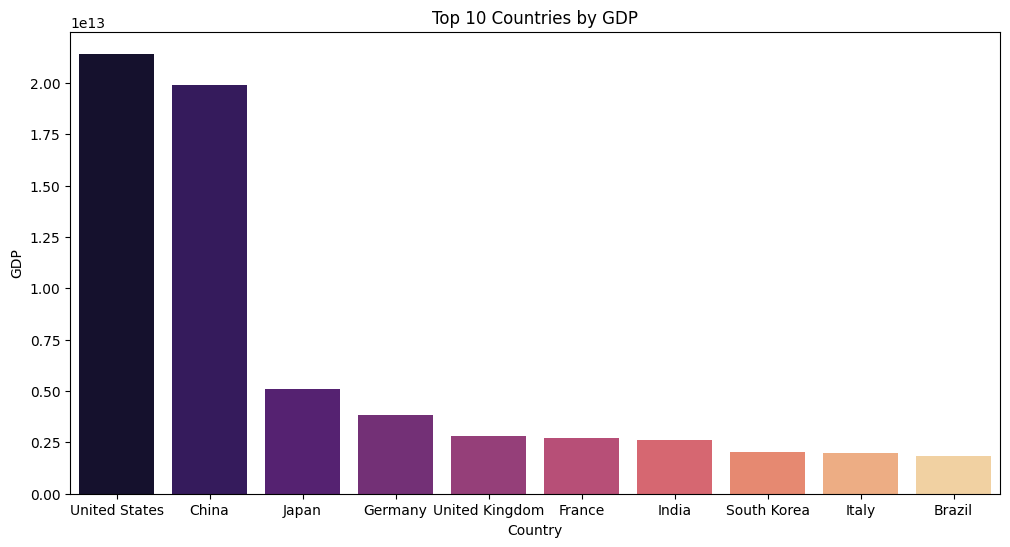

In [44]:
plt.figure(figsize=(12,6))
sns.barplot(x=top_countries["Country"],y=top_countries["GDP"],palette="magma")
plt.xlabel("Country")
plt.ylabel("GDP")
plt.title("Top 10 Countries by GDP")
plt.show()

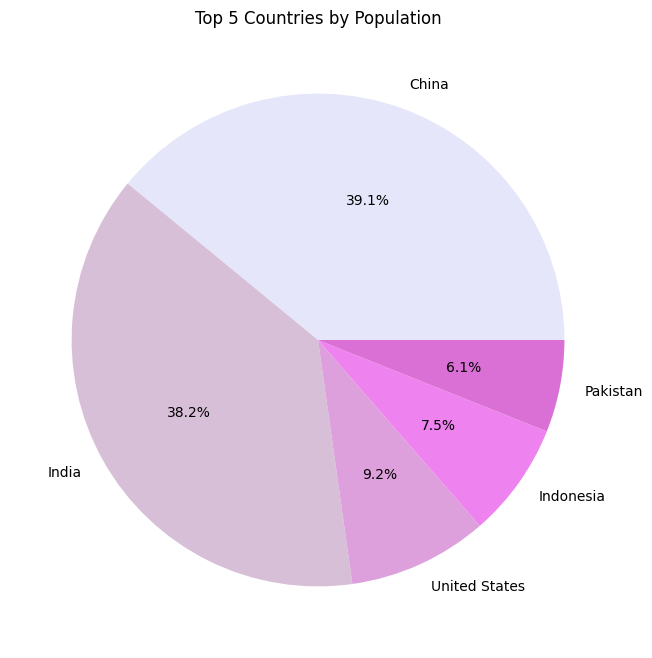

In [45]:
#Pie Chart
top_countries = data.nlargest(5, "Population")
plt.figure(figsize=(8, 8))
plt.pie(top_countries["Population"], labels=top_countries["Country"], autopct='%1.1f%%', colors=["lavender", "thistle", "plum", "violet", "orchid"])
plt.title("Top 5 Countries by Population")
plt.show()

In [46]:
custom_purple = ["#E6E6FA", "#D8BFD8", "#DDA0DD", "#BA55D3", "#800080"]  # درجات بنفسجية
fig = px.pie(
    top_countries, 
    values="Population", 
    names="Country", 
    title="Top 5 Countries by Population", 
    color_discrete_sequence=custom_purple  
)
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

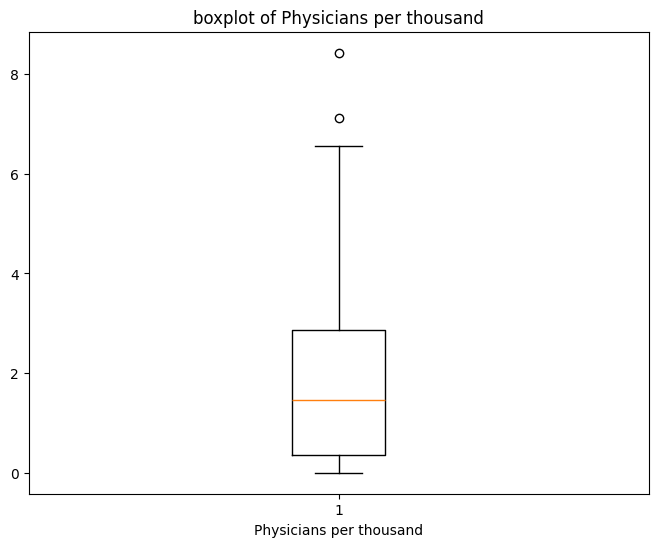

In [47]:
#Box Plot
plt.figure(figsize=(8,6))
plt.boxplot(data["Physicians per thousand"])
plt.xlabel("Physicians per thousand")
plt.title("boxplot of Physicians per thousand")
plt.show()


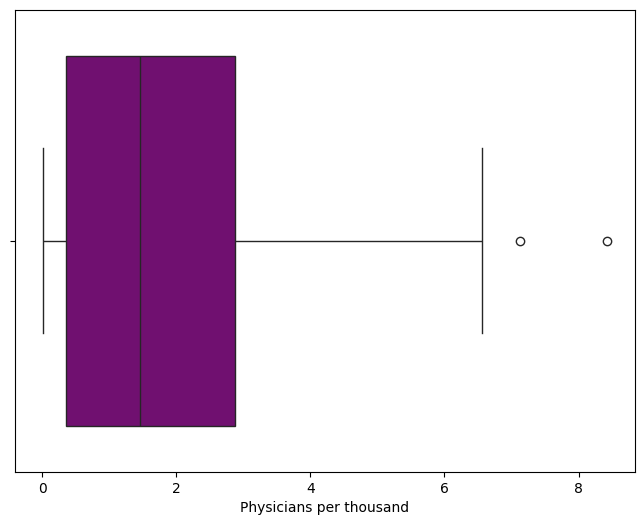

In [48]:
plt.figure(figsize=(8,6))
sns.boxplot(x=data["Physicians per thousand"],color="purple")
plt.xlabel("Physicians per thousand")
plt.show()

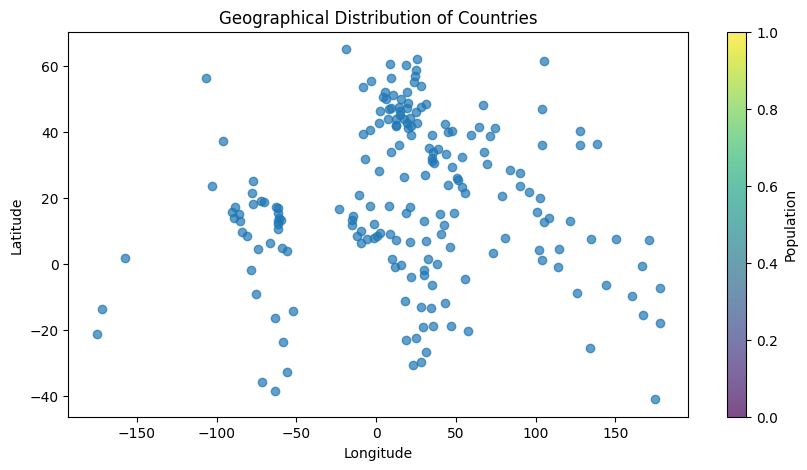

In [49]:
#Geographical Distribution of Countries
plt.figure(figsize=(10,5))
plt.scatter(data["Longitude"], data["Latitude"], cmap="coolwarm",alpha=0.7)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical Distribution of Countries")
plt.colorbar(label="Population")
plt.show()

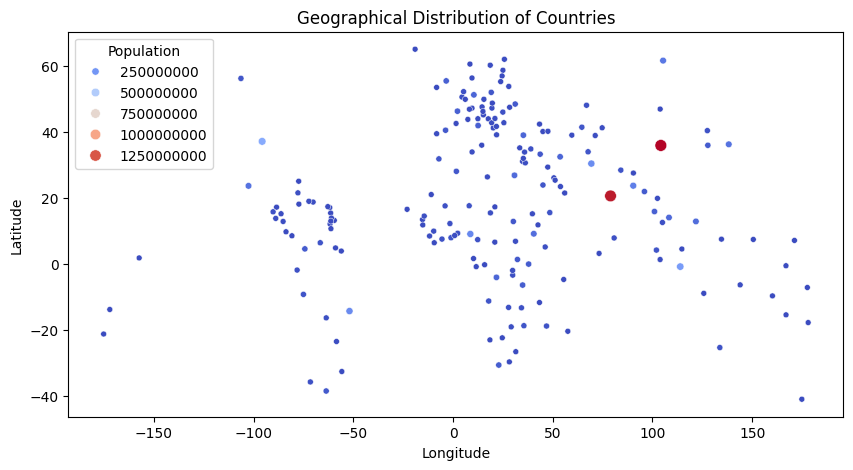

In [50]:
plt.figure(figsize=(10,5))
sns.scatterplot(x=data["Longitude"], y=data["Latitude"], hue=data["Population"], size=data["Population"],palette="coolwarm")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical Distribution of Countries")
plt.show()

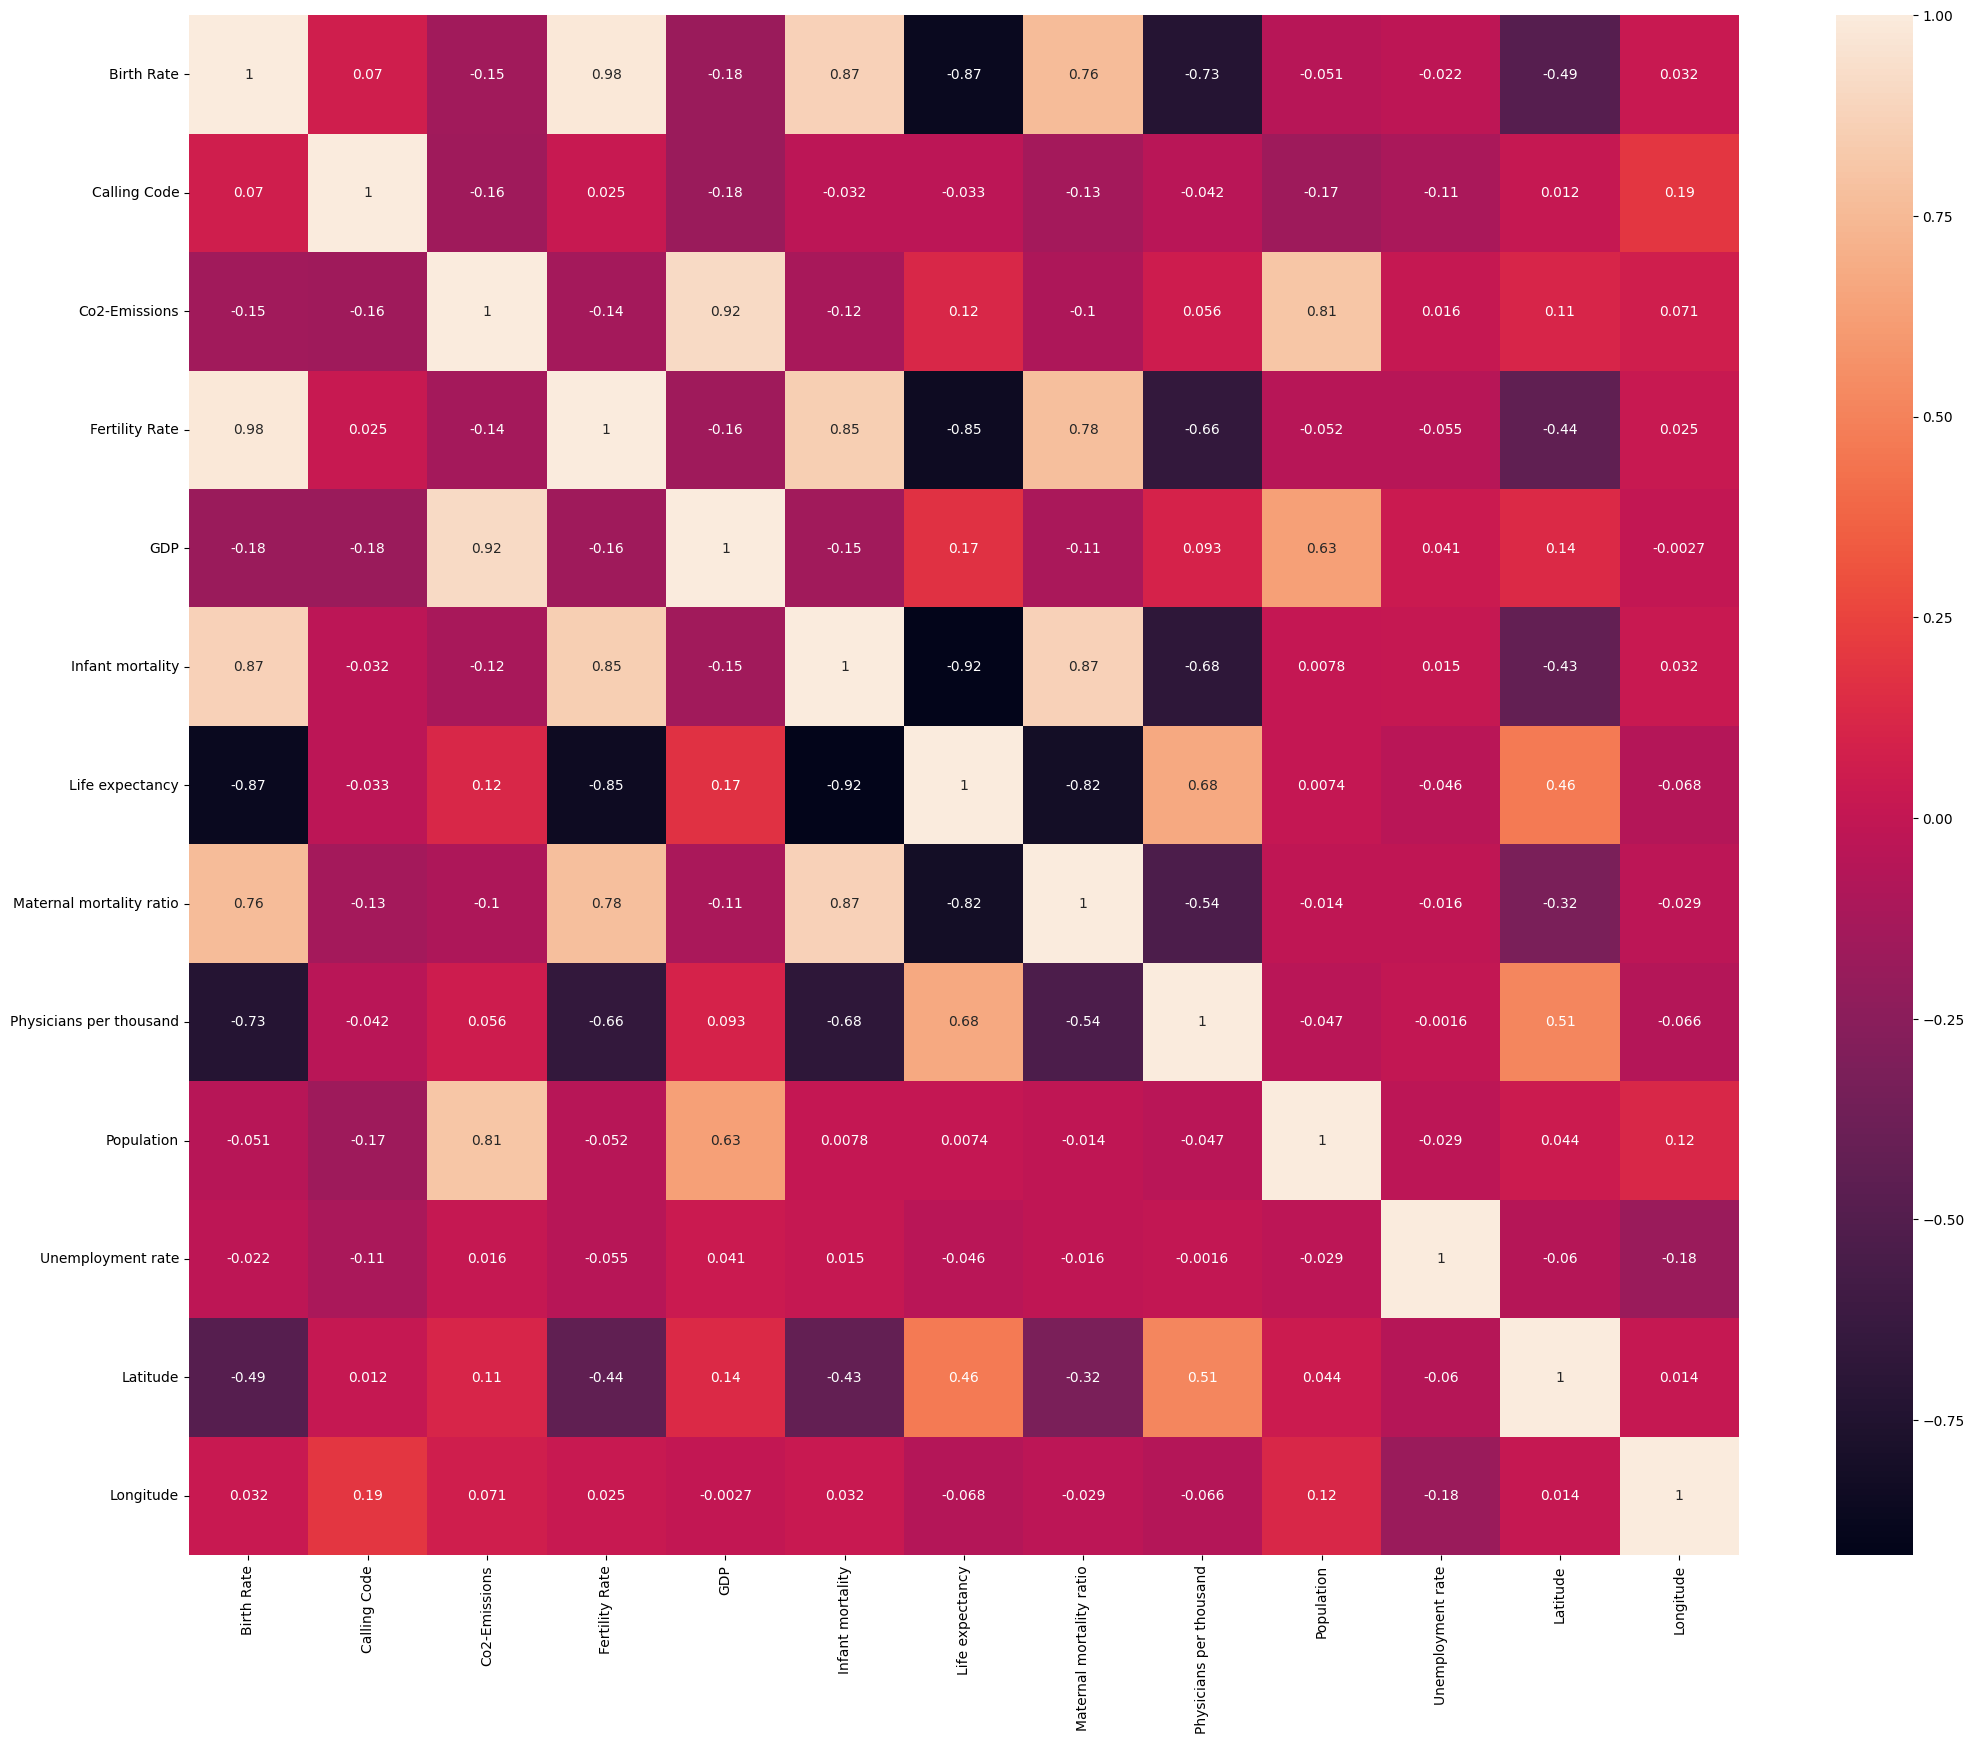

In [51]:
#Heatmap
numerical_data=data.select_dtypes(include=['float64'])
corr_matrix = numerical_data.corr()
plt.figure(figsize=(25,20))
sns.heatmap(corr_matrix, annot=True)
plt.show()